In [318]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, learning_curve,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)

import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost not installed - Section 14 will be skipped gracefully.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

print(f"XGBoost available: {XGBOOST_AVAILABLE}")

XGBoost available: True


In [319]:
df = pd.read_csv("Cancer_Data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [320]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [321]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (569, 33)


In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [323]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,569.0,NaN,NaN,NaN,30371831.432337,125020585.612224,8670.0,869218.0,906024.0,8813129.0,911320502.0
diagnosis,569,2,B,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
radius_mean,569.0,NaN,NaN,NaN,14.127292,3.524049,6.981,11.7,13.37,15.78,28.11
texture_mean,569.0,NaN,NaN,NaN,19.289649,4.301036,9.71,16.17,18.84,21.8,39.28
perimeter_mean,569.0,NaN,NaN,NaN,91.969033,24.298981,43.79,75.17,86.24,104.1,188.5
area_mean,569.0,NaN,NaN,NaN,654.889104,351.914129,143.5,420.3,551.1,782.7,2501.0
smoothness_mean,569.0,NaN,NaN,NaN,0.09636,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,NaN,NaN,NaN,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,NaN,NaN,NaN,0.088799,0.07972,0.0,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,NaN,NaN,NaN,0.048919,0.038803,0.0,0.02031,0.0335,0.074,0.2012


In [324]:
missing_table = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().sum() / len(df) * 100).round(2),
})
missing_table = missing_table[missing_table["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Data types:")
print(df.dtypes)
print()
missing_table

Duplicate rows: 0

Data types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst       

,Missing Count,Missing %
Unnamed: 32,569,100.0


In [325]:
print(df.isna().sum().sort_values(ascending=False).head())


Unnamed: 32                569
compactness_se               0
fractal_dimension_worst      0
symmetry_worst               0
concave points_worst         0
dtype: int64


In [326]:
df = df.drop(columns=['Unnamed: 32', 'id'])
print( df.duplicated().sum())
print( df.shape)
df.head()




0
(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [327]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(df['diagnosis'].value_counts())
df['diagnosis'].head()


diagnosis
0    357
1    212
Name: count, dtype: int64


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

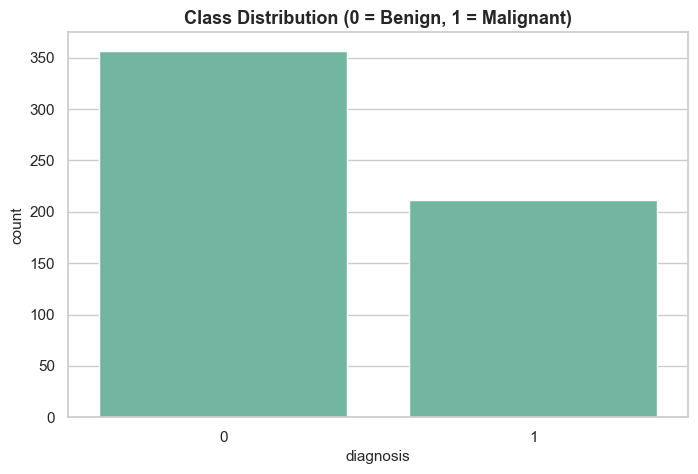

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


In [328]:
sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution (0 = Benign, 1 = Malignant)')
plt.show()

print(df['diagnosis'].value_counts(normalize=True) * 100)


In [329]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

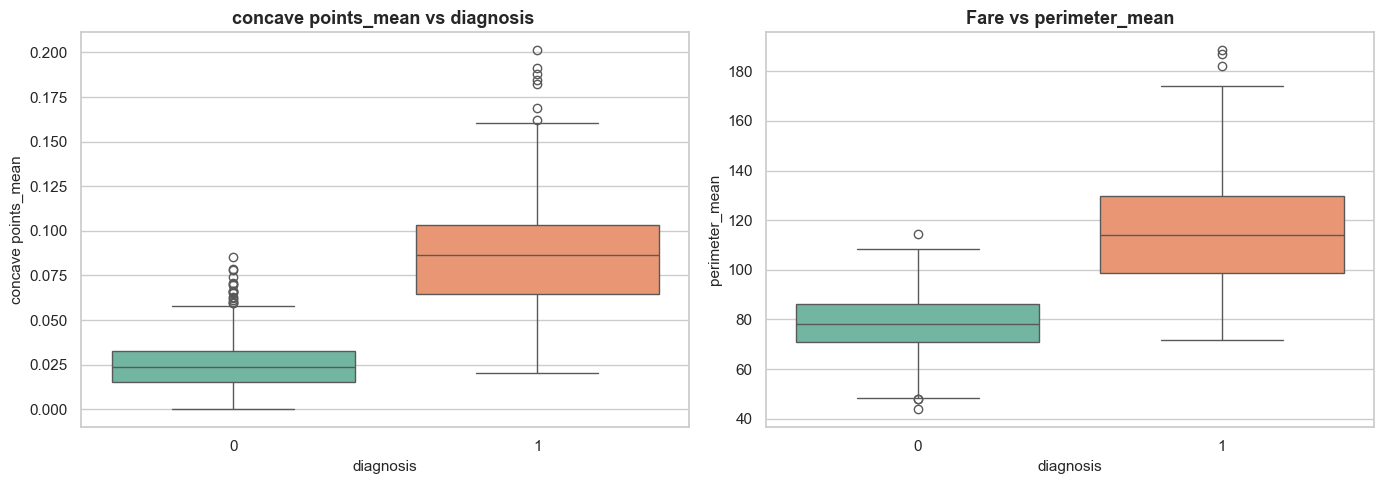

In [330]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="diagnosis", y="concave points_mean", ax=axes[0], hue="diagnosis",
            palette="Set2", legend=False)
axes[0].set_title("concave points_mean vs diagnosis ")

sns.boxplot(data=df, x="diagnosis", y="perimeter_mean", ax=axes[1], hue="diagnosis",
            palette="Set2", legend=False)
axes[1].set_title("Fare vs perimeter_mean")
plt.tight_layout()
plt.show()

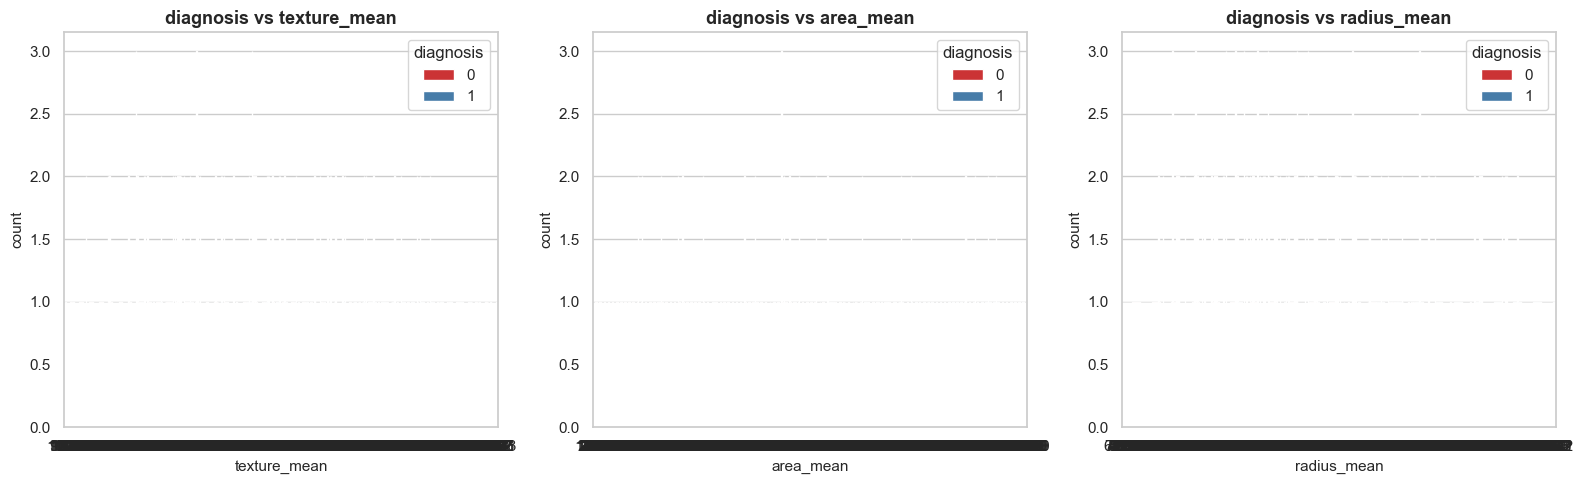

In [331]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(data=df, x="texture_mean", hue="diagnosis", ax=axes[0], palette="Set1")
axes[0].set_title("diagnosis vs texture_mean")

sns.countplot(data=df, x="area_mean", hue="diagnosis", ax=axes[1], palette="Set1")
axes[1].set_title("diagnosis vs area_mean")

sns.countplot(data=df, x="radius_mean", hue="diagnosis", ax=axes[2], palette="Set1")
axes[2].set_title("diagnosis vs radius_mean")
plt.tight_layout()
plt.show()

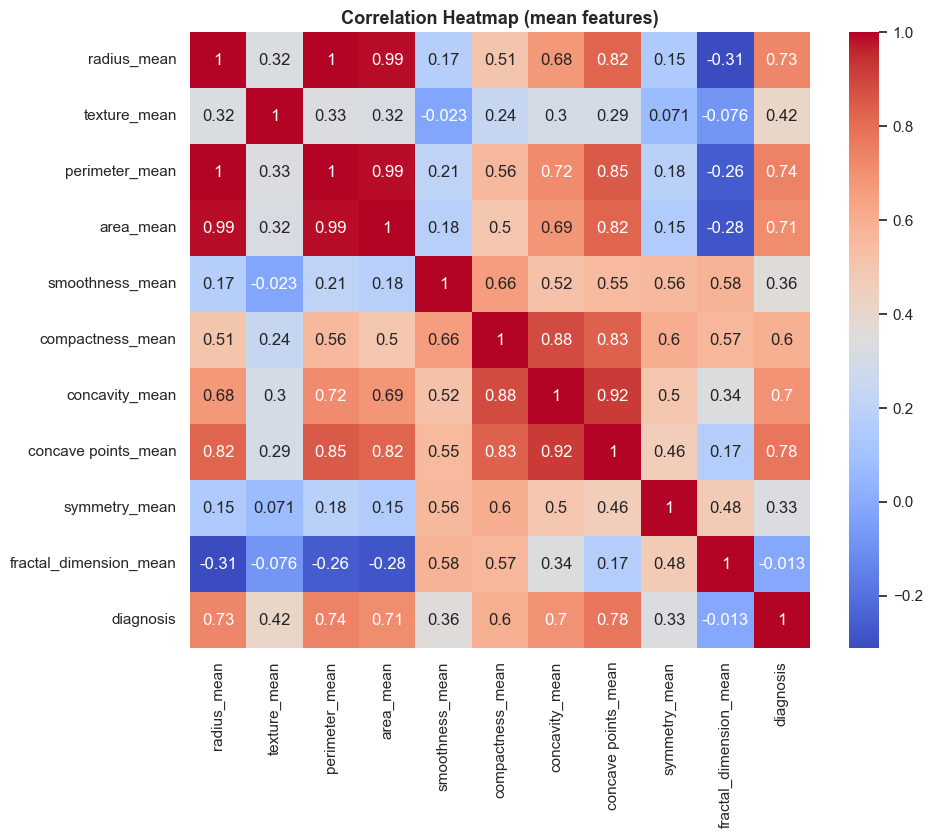

In [332]:
mean_cols = [c for c in df.columns if '_mean' in c] + ['diagnosis']
plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (mean features)')
plt.show()


In [333]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (455, 30) | X_test: (114, 30)


In [334]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print( X_train.iloc[0].values[:5])
print(X_train_scaled[0][:5])


[1.602e+01 2.324e+01 1.027e+02 7.978e+02 8.206e-02]
[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]


In [335]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [336]:
y_pred_lr = model.predict(X_test_scaled)

In [337]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

import warnings
warnings.filterwarnings("error", category=UserWarning)

Accuracy: 0.9649


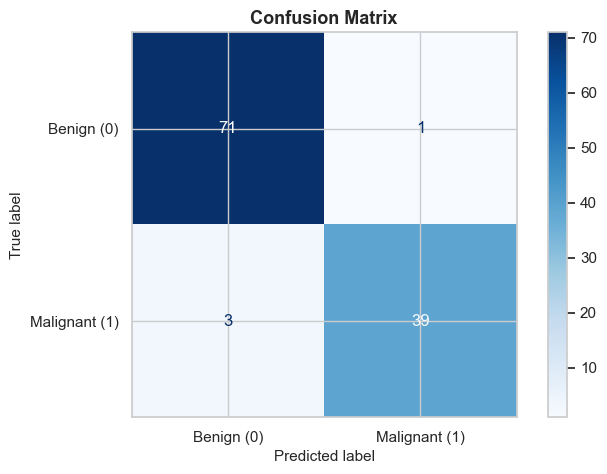

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC: 0.9960


In [338]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benign (0)', 'Malignant (1)']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")


In [339]:
import numpy as np
print(np.unique(y_pred_lr, return_counts=True))

(array([0, 1]), array([74, 40]))


In [340]:
print(classification_report(y_test, y_pred_lr, target_names=["Malignant", "Benign"]))

              precision    recall  f1-score   support

   Malignant       0.96      0.99      0.97        72
      Benign       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [341]:
tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)

print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves: {tree_model.get_n_leaves()}")
print(f"Train accuracy: {accuracy_score(y_train, tree_model.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, tree_model.predict(X_test)):.4f}")

Tree depth: 8
Number of leaves: 24
Train accuracy: 1.0000
Test accuracy:  0.9298


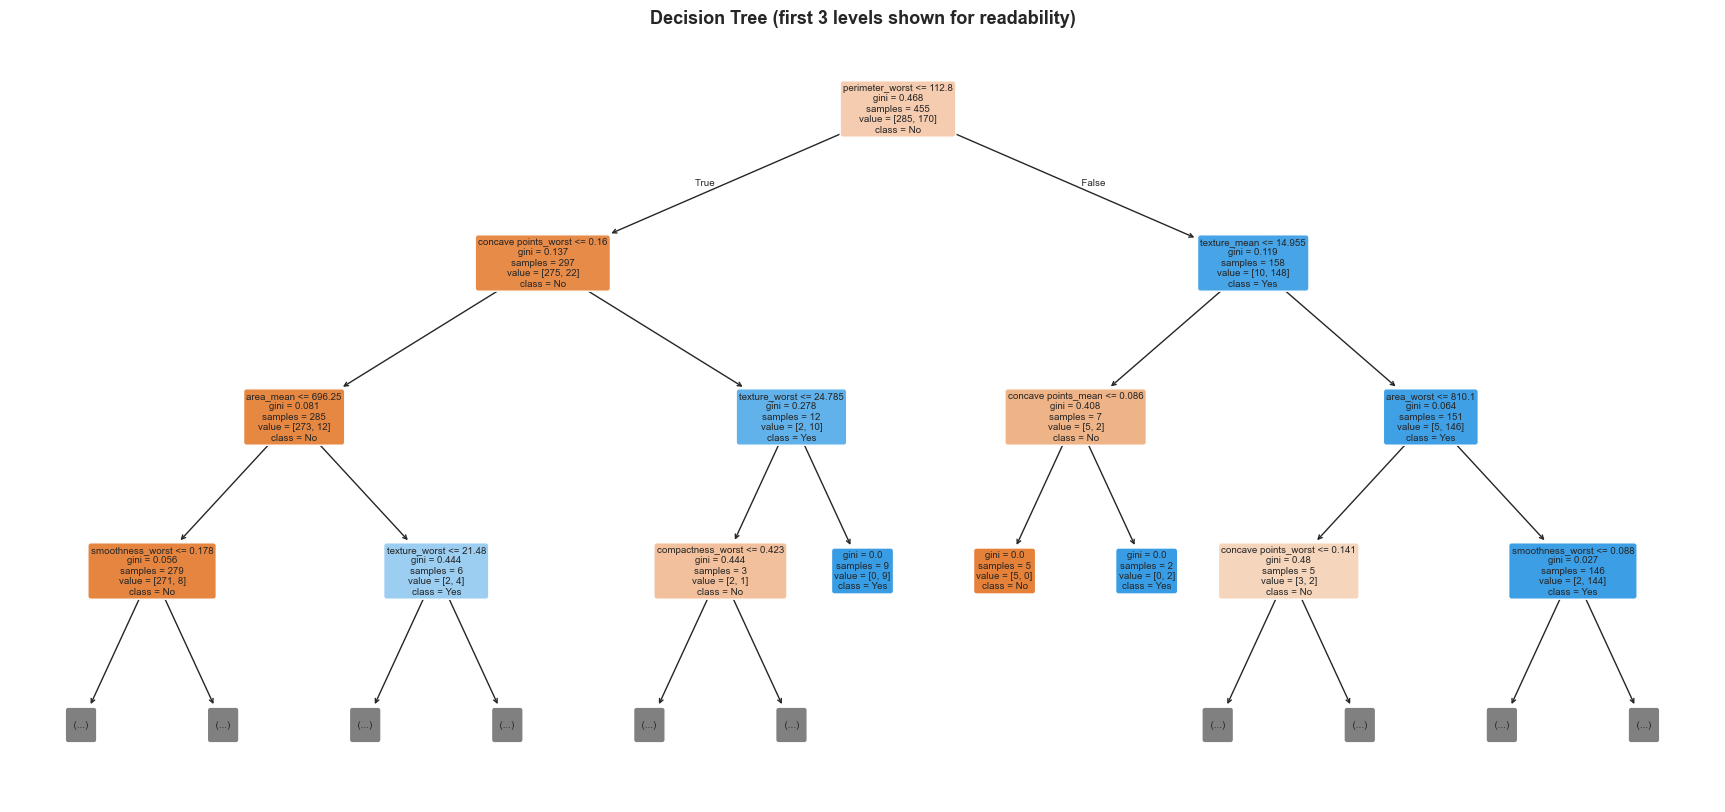

In [342]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model, feature_names=X_train.columns, class_names=["No", "Yes"],
    filled=True, rounded=True, fontsize=7, max_depth=3,
)
plt.title("Decision Tree (first 3 levels shown for readability)")
plt.show()

In [343]:
importance_table = (
    pd.Series(tree_model.feature_importances_, index=X_train.columns, name="Importance")
    .sort_values(ascending=False)
)
importance_table.to_frame()

,Importance
perimeter_worst,0.727477
concave points_worst,0.078970
smoothness_worst,0.040833
texture_mean,0.037871
texture_worst,0.022545
area_mean,0.022452
radius_worst,0.017530
area_worst,0.015606
concave points_mean,0.013416
concavity_se,0.007043


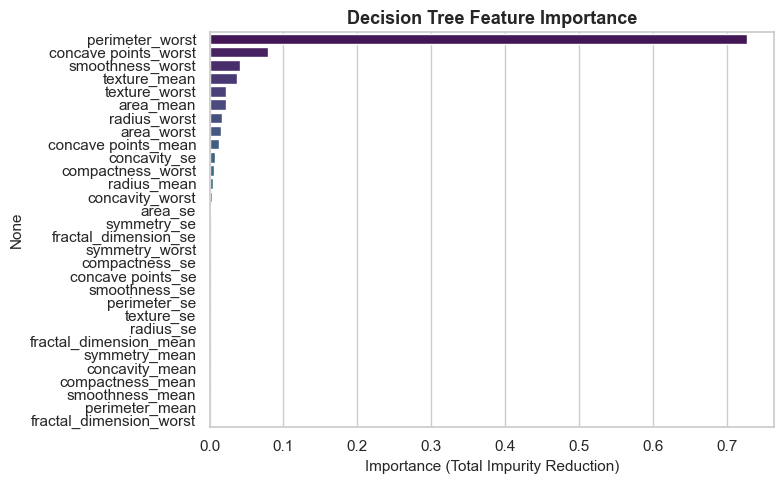

In [344]:
plt.figure(figsize=(8, 5))
sns.barplot(x=importance_table.values, y=importance_table.index, hue=importance_table.index,
            palette="viridis", legend=False)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance (Total Impurity Reduction)")
plt.tight_layout()
plt.show()

In [345]:
forest_model = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, oob_score=True
)
forest_model.fit(X_train, y_train)

single_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
single_tree.fit(X_train, y_train)

forest_vs_tree = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [
        accuracy_score(y_train, single_tree.predict(X_train)),
        accuracy_score(y_train, forest_model.predict(X_train)),
    ],
    "Test Accuracy": [
        accuracy_score(y_test, single_tree.predict(X_test)),
        accuracy_score(y_test, forest_model.predict(X_test)),
    ],
}).round(4)

print(f"Number of trees: {forest_model.n_estimators}")
print(f"OOB Score: {forest_model.oob_score_:.4f}")
forest_vs_tree

Number of trees: 200
OOB Score: 0.9538


,Model,Train Accuracy,Test Accuracy
0,Decision Tree,1.0,0.9298
1,Random Forest,1.0,0.9649


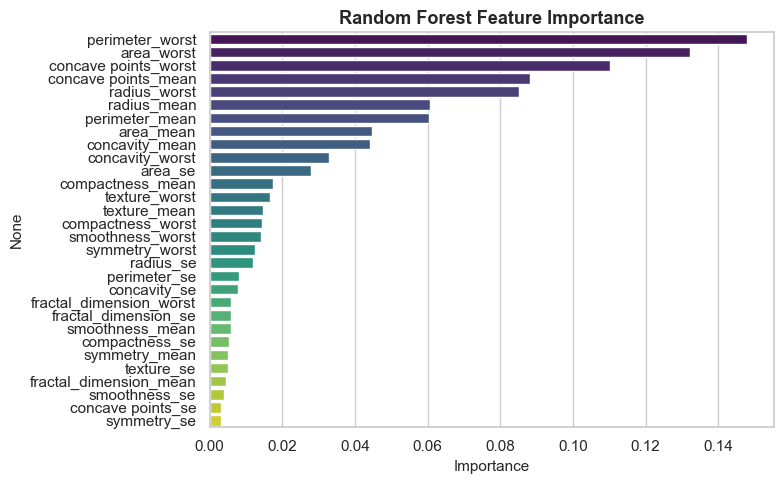

In [346]:
rf_importance = (
    pd.Series(forest_model.feature_importances_, index=X_train.columns, name="Importance")
    .sort_values(ascending=False)
)
plt.figure(figsize=(8, 5))
sns.barplot(x=rf_importance.values, y=rf_importance.index, hue=rf_importance.index,
            palette="viridis", legend=False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [347]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [348]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [349]:
y_pred = model.predict(X_test)

In [350]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [351]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



[[72  0]
 [ 4 38]]


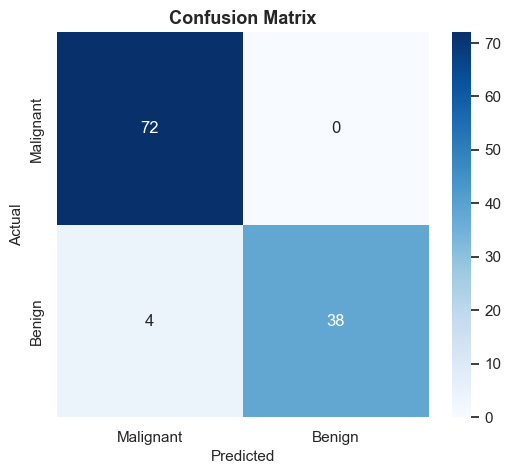

In [352]:
cm = confusion_matrix(y_test, y_pred)

print(cm)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [353]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

perimeter_worst         0.278365
radius_worst            0.251420
concave points_mean     0.129637
concave points_worst    0.080885
concavity_mean          0.026811
concavity_worst         0.025531
area_mean               0.020768
texture_mean            0.019833
texture_worst           0.017856
concavity_se            0.016952
dtype: float32

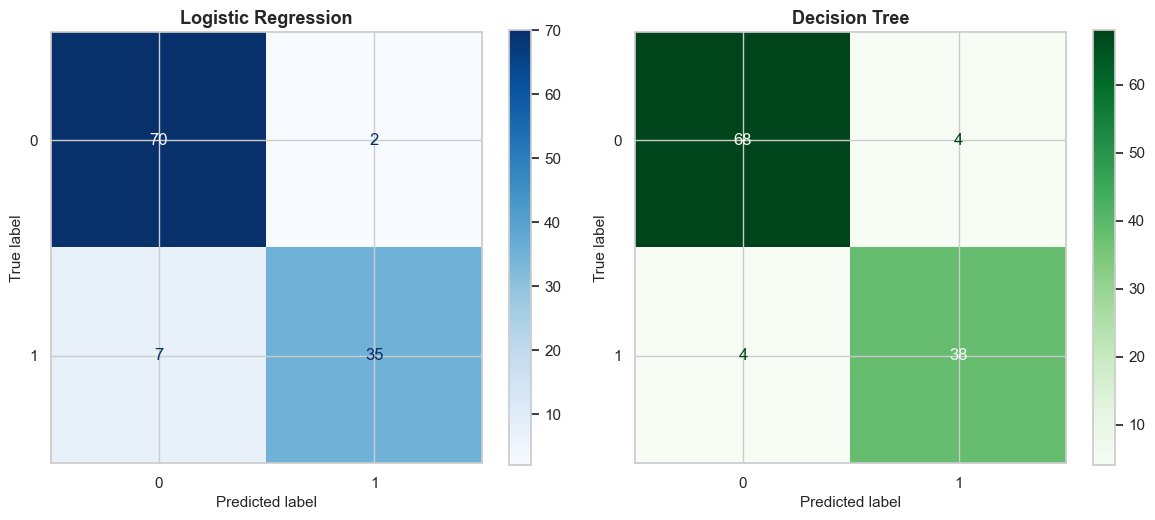

In [355]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

log_model = LogisticRegression(max_iter=1000)
dt_model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

y_pred = model.predict(X_test)
dt_pred = dt_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

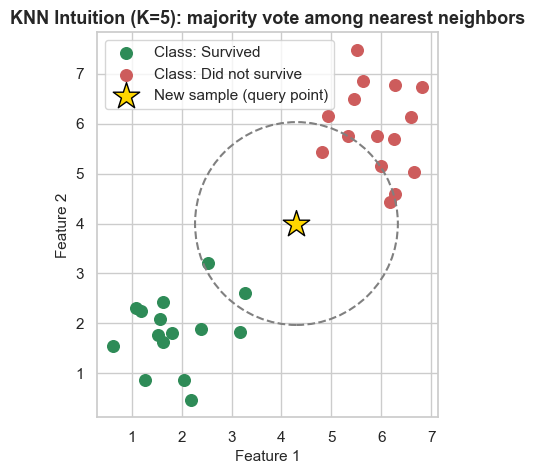

In [ ]:
np.random.seed(RANDOM_STATE)

# Synthetic 2D illustration (not the real dataset) purely to visualize the concept
class_a = np.random.normal(loc=(2, 2), scale=0.8, size=(15, 2))   
class_b = np.random.normal(loc=(6, 6), scale=0.8, size=(15, 2))   
query_point = np.array([4.3, 4.0])

fig, ax = plt.subplots()
ax.scatter(class_a[:, 0], class_a[:, 1], color="seagreen", label="Class: Survived", s=70)
ax.scatter(class_b[:, 0], class_b[:, 1], color="indianred", label="Class: Did not survive", s=70)
ax.scatter(*query_point, color="gold", edgecolor="black", marker="*", s=400, label="New sample (query point)")

# draw circle around the K=5 nearest neighbors
all_points = np.vstack([class_a, class_b])
dists = np.linalg.norm(all_points - query_point, axis=1)
k = 5
nearest_idx = np.argsort(dists)[:k]
radius = dists[nearest_idx].max()
circle = plt.Circle(query_point, radius, color="gray", fill=False, linestyle="--", linewidth=1.5)
ax.add_patch(circle)

ax.set_title(f"KNN Intuition (K={k}): majority vote among nearest neighbors")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.set_aspect("equal")
plt.show()

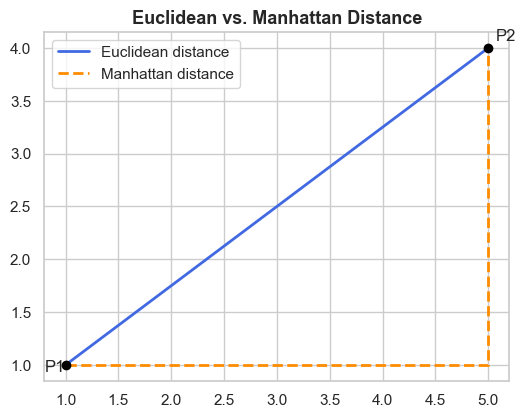

Euclidean distance: 5.00
Manhattan distance: 7.00


In [ ]:
p1 = np.array([1, 1])
p2 = np.array([5, 4])

fig, ax = plt.subplots(figsize=(6, 6))

# Euclidean: straight line
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="royalblue", linewidth=2, label="Euclidean distance")

# Manhattan: grid path
ax.plot([p1[0], p2[0], p2[0]], [p1[1], p1[1], p2[1]], color="darkorange", linewidth=2, linestyle="--", label="Manhattan distance")

ax.scatter(*p1, color="black", zorder=5)
ax.scatter(*p2, color="black", zorder=5)
ax.annotate("P1", p1, textcoords="offset points", xytext=(-15, -5))
ax.annotate("P2", p2, textcoords="offset points", xytext=(5, 5))

ax.set_title("Euclidean vs. Manhattan Distance")
ax.legend()
ax.set_aspect("equal")
plt.show()

euclidean = np.linalg.norm(p2 - p1)
manhattan = np.sum(np.abs(p2 - p1))
print(f"Euclidean distance: {euclidean:.2f}")
print(f"Manhattan distance: {manhattan:.2f}")

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions: ", y_pred[:10])
print("First 10 actual labels:", y_test.values[:10])

First 10 predictions:  [0 1 0 0 0 0 1 0 0 0]
First 10 actual labels: [0 1 0 1 0 0 1 0 0 0]


In [ ]:
def print_metrics(y_true, y_pred, y_proba=None, model_name="Model"):
    """Reusable helper to print a standard classification metrics summary."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC AUC  : {auc:.4f}")
        return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

baseline_metrics = print_metrics(y_test, y_pred, y_proba, model_name="KNN (K=5, baseline)")

--- KNN (K=5, baseline) ---
Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383
ROC AUC  : 0.9823


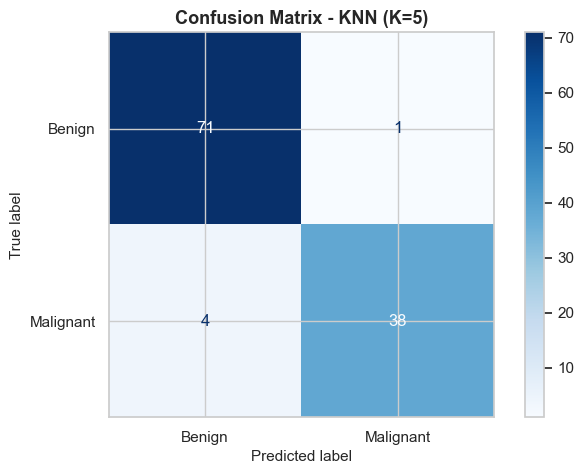

Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN (K=5)")
plt.show()

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scores = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

print(scores)

[0.8947368421052632, 0.9122807017543859, 0.9210526315789473, 0.9210526315789473, 0.9122807017543859, 0.9210526315789473, 0.9122807017543859, 0.9122807017543859, 0.9210526315789473, 0.9210526315789473, 0.9473684210526315, 0.9298245614035088, 0.9385964912280702, 0.9385964912280702, 0.9298245614035088, 0.9385964912280702, 0.9385964912280702, 0.9298245614035088, 0.9385964912280702, 0.9210526315789473]


In [ ]:
best_k = np.argmax(scores) + 1

print(best_k)

11


In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

,n_neighbors,np.int64(11)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


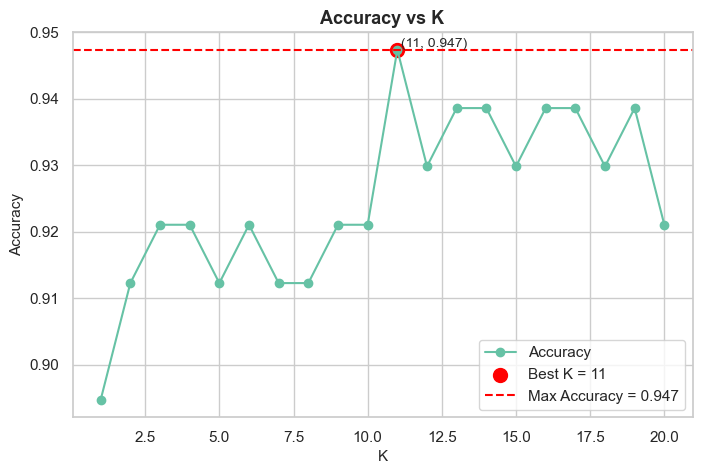

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

best_accuracy = max(scores)
best_k = np.argmax(scores) + 1   

plt.figure(figsize=(8,5))

plt.plot(range(1,21), scores, marker='o', label='Accuracy')

plt.scatter(best_k, best_accuracy, color='red', s=100,
            label=f'Best K = {best_k}')

plt.axhline(y=best_accuracy, color='red', linestyle='--',
            label=f'Max Accuracy = {best_accuracy:.3f}')

plt.text(best_k, best_accuracy,
         f' ({best_k}, {best_accuracy:.3f})',
         fontsize=10, va='bottom')

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
new_sample = scaler.transform(X.iloc[[0]])
prediction = model.predict(new_sample)
print(prediction)

[0]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.921053
1        Decision Tree  0.929825
2                  KNN  0.912281


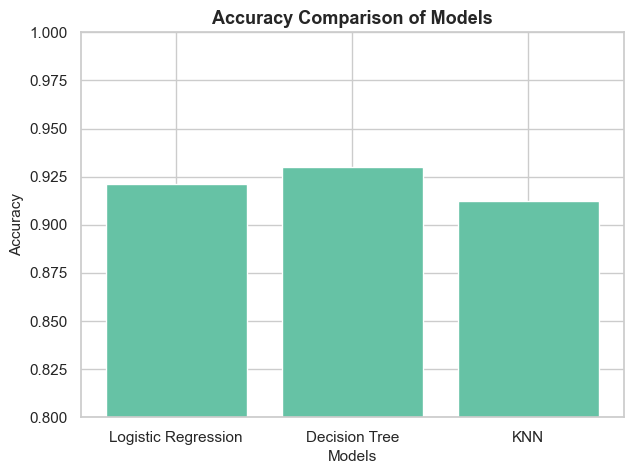

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
model = GaussianNB()

In [ ]:
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9210526315789473


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[69  3]
 [ 6 36]]


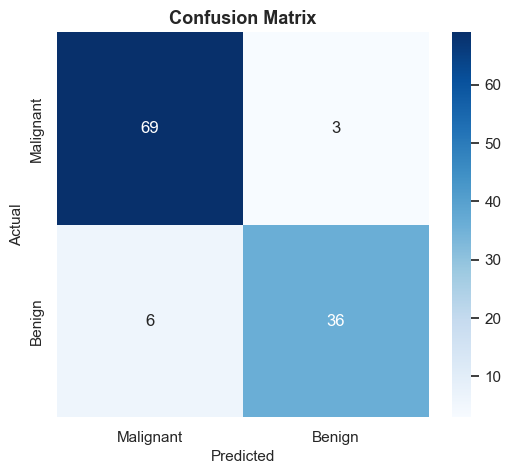

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
new_patient = X.iloc[[0]]
new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print(prediction)


[1]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
from sklearn.naive_bayes import GaussianNB

naive_model = GaussianNB()

naive_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [ ]:
prob = model.predict_proba(new_patient)

print(prob)

[[1.02698982e-154 1.00000000e+000]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                 Model  Accuracy
2        Random Forest  0.973684
0  Logistic Regression  0.964912
3              XGBoost  0.964912
4                  KNN  0.956140
1        Decision Tree  0.929825
5          Naive Bayes  0.921053


In [ ]:
new_patient = pd.DataFrame({
    "radius_mean":[14.5],
    "texture_mean":[20.1],
    "perimeter_mean":[95.4],
    "area_mean":[650],
    "smoothness_mean":[0.10],
    "compactness_mean":[0.12],
    "concavity_mean":[0.08],
    "concave points_mean":[0.05],
    "symmetry_mean":[0.18],
    "fractal_dimension_mean":[0.06],

    "radius_se":[0.40],
    "texture_se":[1.20],
    "perimeter_se":[2.90],
    "area_se":[38],
    "smoothness_se":[0.005],
    "compactness_se":[0.020],
    "concavity_se":[0.025],
    "concave points_se":[0.010],
    "symmetry_se":[0.018],
    "fractal_dimension_se":[0.003],

    "radius_worst":[17.2],
    "texture_worst":[26.5],
    "perimeter_worst":[110],
    "area_worst":[850],
    "smoothness_worst":[0.14],
    "compactness_worst":[0.25],
    "concavity_worst":[0.30],
    "concave points_worst":[0.12],
    "symmetry_worst":[0.28],
    "fractal_dimension_worst":[0.09]
})
new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)
if prediction[0] == 1:
    print(" Prediction: Malignant (Cancer)")
else:
    print(" Prediction: Benign (No Cancer)")
    
prob = model.predict_proba(new_patient_scaled)

print(f"Probability of Malignant: {prob[0][1]*100:.2f}%")
print(f"Probability of Benign: {prob[0][0]*100:.2f}%")

 Prediction: Benign (No Cancer)
Probability of Malignant: 0.23%
Probability of Benign: 99.77%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC
svm_linear = SVC(kernel='linear')

In [ ]:

svm_linear.fit(X_train_processed, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
# Train a baseline Linear SVM
svm_linear = SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE, probability=True)
svm_linear.fit(X_train_processed, y_train)

# Predictions on the TRAINING set
y_train_pred_linear = svm_linear.predict(X_train_processed)

# Predictions on the TESTING set
y_test_pred_linear = svm_linear.predict(X_test_processed)

print("Linear SVM trained successfully.")
print(f"Training accuracy: {accuracy_score(y_train, y_train_pred_linear):.4f}")
print(f"Testing accuracy:  {accuracy_score(y_test, y_test_pred_linear):.4f}")


Linear SVM trained successfully.
Training accuracy: 0.9890
Testing accuracy:  0.9649


===== Linear SVM — Evaluation Metrics =====
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
ROC AUC: 0.9914

===== Linear SVM — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      1.00      0.97        72
      Benign       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



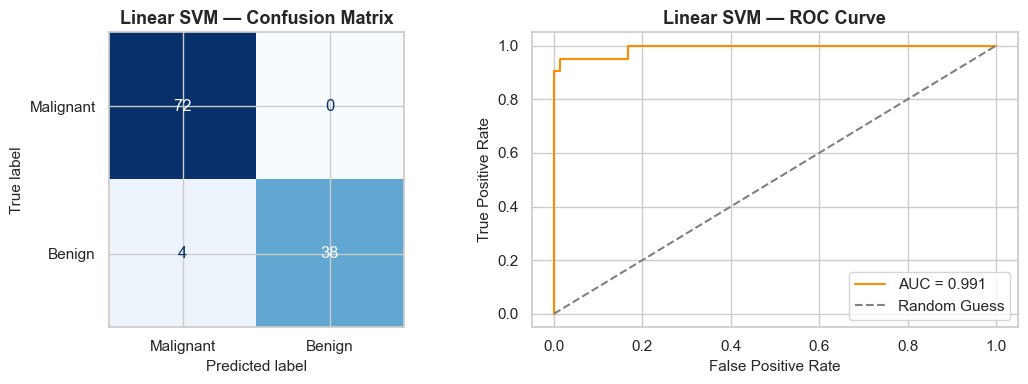

In [ ]:
def evaluate_model(model, X_te, y_te, model_name="Model"):
    '''
    Compute and display a full suite of classification metrics for a fitted model.

    Parameters
    ----------
    model : fitted classifier with .predict() (and ideally .predict_proba())
    X_te  : test features (already preprocessed)
    y_te  : true test labels
    model_name : str, label used in printed output and plot titles

    Returns
    -------
    dict of computed metric values
    '''

    y_pred = model.predict(X_te)

    # Predict probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = None

    metrics = {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1 Score": f1_score(y_te, y_pred),
    }

    if y_proba is not None:
        metrics["ROC AUC"] = roc_auc_score(y_te, y_proba)

    print(f"===== {model_name} — Evaluation Metrics =====")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")

    print(f"\n===== {model_name} — Classification Report =====")
    print(
        classification_report(
            y_te,
            y_pred,
            target_names=["Malignant", "Benign"]
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)

    fig, axes = plt.subplots(
        1,
        2 if y_proba is not None else 1,
        figsize=(11, 4)
    )

    ax0 = axes[0] if y_proba is not None else axes

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Malignant", "Benign"]
    )

    disp.plot(
        ax=ax0,
        cmap="Blues",
        colorbar=False
    )

    ax0.set_title(f"{model_name} — Confusion Matrix")

    # ROC Curve
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_te, y_proba)

        axes[1].plot(
            fpr,
            tpr,
            label=f"AUC = {metrics['ROC AUC']:.3f}",
            color="darkorange"
        )

        axes[1].plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="gray",
            label="Random Guess"
        )

        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].set_title(f"{model_name} — ROC Curve")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

    return metrics


# Evaluate Linear SVM
linear_metrics = evaluate_model(
    svm_linear,
    X_test,
    y_test,
    model_name="Linear SVM"
)

In [ ]:

kernels = ["linear", "poly", "rbf", "sigmoid"]
kernel_models = {}
kernel_results = []

for k in kernels:
    model = SVC(kernel=k, C=1.0, random_state=RANDOM_STATE, probability=True)
    model.fit(X_train_processed, y_train)
    kernel_models[k] = model

    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    kernel_results.append({
        "Kernel": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
    })

kernel_comparison_df = pd.DataFrame(kernel_results).set_index("Kernel").round(4)
kernel_comparison_df


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Kernel,,,,,
linear,0.9649,1.0000,0.9048,0.9500,0.9914
poly,0.8860,1.0000,0.6905,0.8169,0.9967
rbf,0.9737,1.0000,0.9286,0.9630,0.9947
sigmoid,0.9474,0.9737,0.8810,0.9250,0.9954


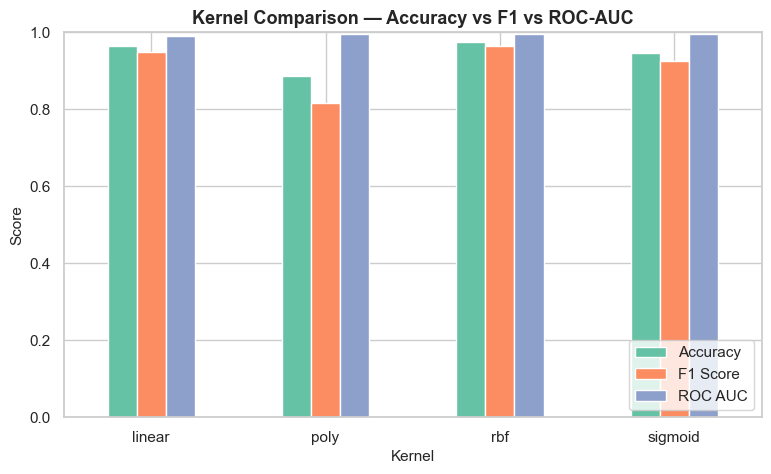

In [ ]:

# Visualize the comparison
kernel_comparison_df[["Accuracy", "F1 Score", "ROC AUC"]].plot(kind="bar", figsize=(9, 5))
plt.title("Kernel Comparison — Accuracy vs F1 vs ROC-AUC")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()


===== Model — Evaluation Metrics =====
Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1 Score: 0.9383
ROC AUC: 0.9823

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      0.99      0.97        72
      Benign       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



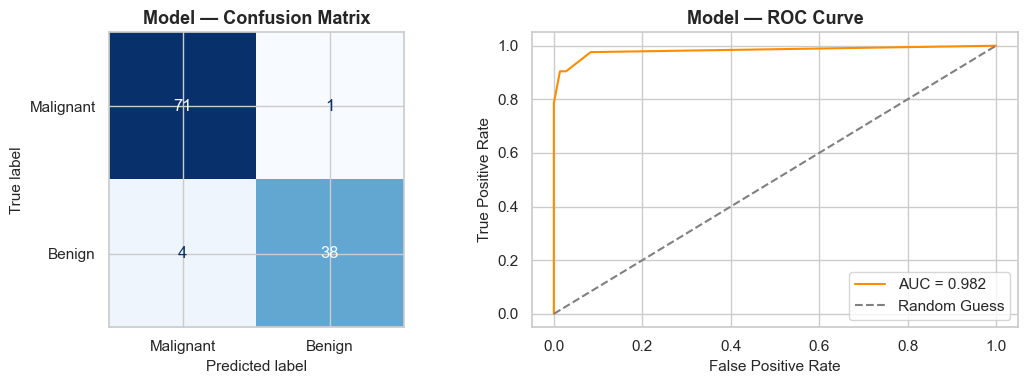

===== Model — Evaluation Metrics =====
Accuracy: 0.6316
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.7940

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.63      1.00      0.77        72
      Benign       0.00      0.00      0.00        42

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



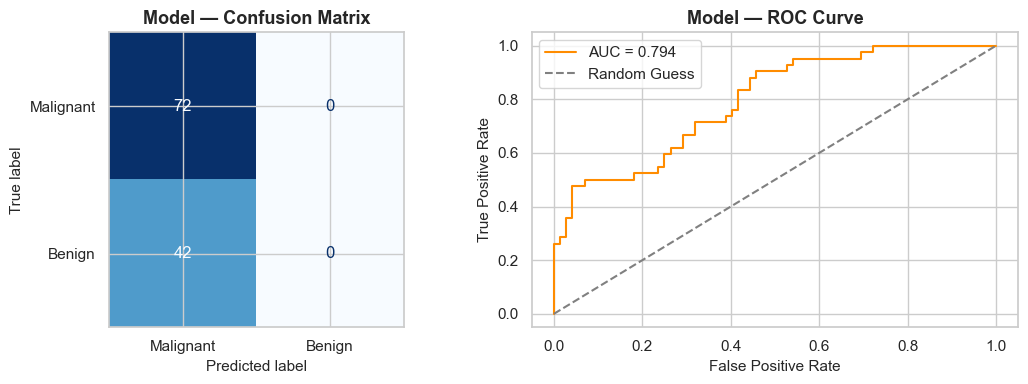

===== Model — Evaluation Metrics =====
Accuracy: 0.7281
Precision: 0.9231
Recall: 0.2857
F1 Score: 0.4364
ROC AUC: 0.6359

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.70      0.99      0.82        72
      Benign       0.92      0.29      0.44        42

    accuracy                           0.73       114
   macro avg       0.81      0.64      0.63       114
weighted avg       0.78      0.73      0.68       114



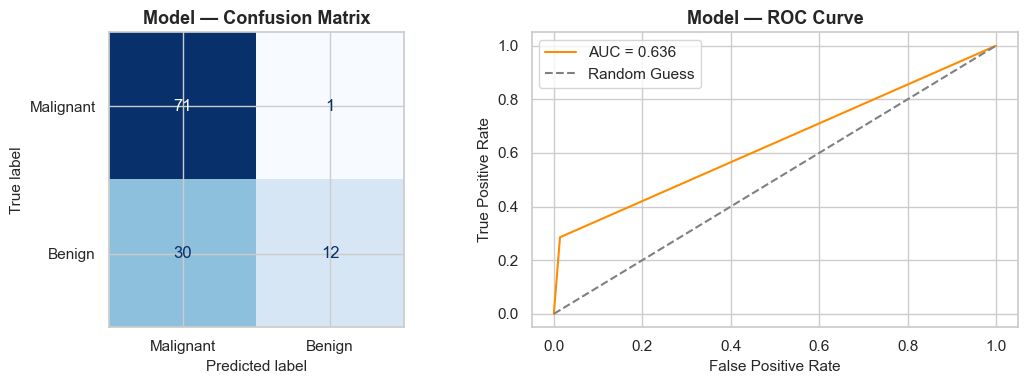

===== Model — Evaluation Metrics =====
Accuracy: 0.9211
Precision: 0.9231
Recall: 0.8571
F1 Score: 0.8889
ROC AUC: 0.9891

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.92      0.96      0.94        72
      Benign       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



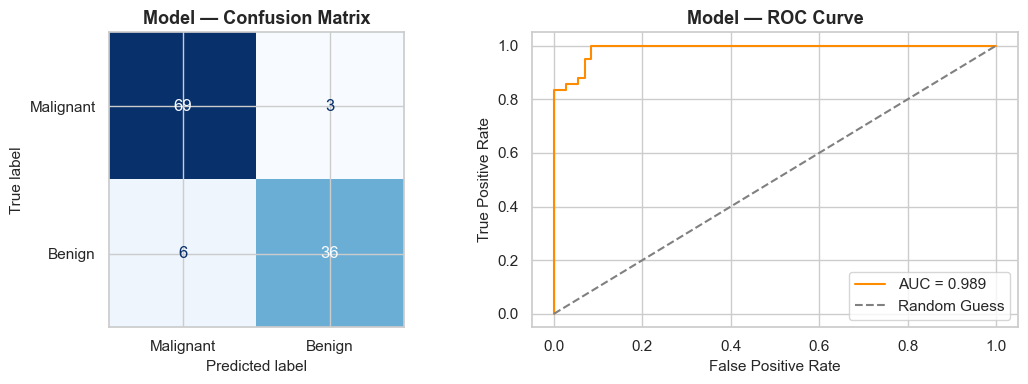

===== Model — Evaluation Metrics =====
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
ROC AUC: 0.9914

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      1.00      0.97        72
      Benign       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



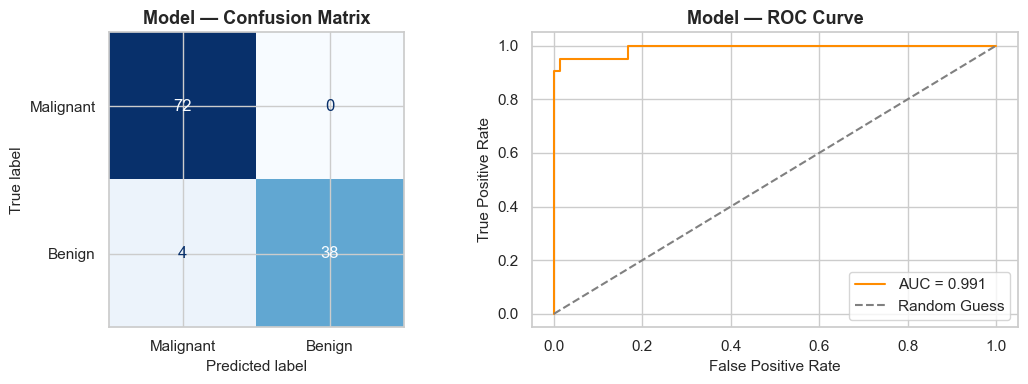

,Accuracy,Precision,Recall,F1 Score,ROC AUC
KNN,0.9561,0.9744,0.9048,0.9383,0.9823
Logistic Regression,0.6316,0.0000,0.0000,0.0000,0.7940
Decision Tree,0.7281,0.9231,0.2857,0.4364,0.6359
Naive Bayes,0.9211,0.9231,0.8571,0.8889,0.9891
SVM,0.9649,1.0000,0.9048,0.9500,0.9914


In [ ]:
comparison = pd.DataFrame(
    [
        evaluate_model(knn_model, X_test, y_test),
        evaluate_model(log_model, X_test, y_test),
        evaluate_model(dt_model, X_test, y_test),
        evaluate_model(naive_model, X_test, y_test),
        evaluate_model(svm_linear, X_test, y_test),
    ],
    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    index=[
        "KNN",
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes",
        "SVM"
    ]
).round(4)

comparison

In [ ]:
import joblib

joblib.dump(svm_linear, "svm_model.pkl")

['svm_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

In [ ]:
nn_model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [ ]:
y_pred = nn_model.predict(X_test_scaled)

y_prob = nn_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1 Score : 0.95
ROC AUC  : 0.9937169312169312


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



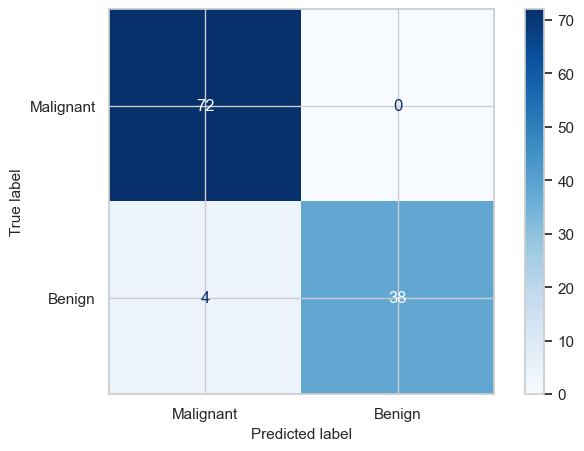

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
)

disp.plot(cmap="Blues")
plt.show()

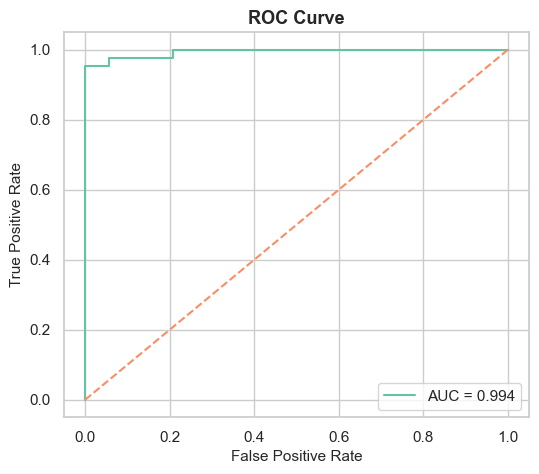

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

===== Model — Evaluation Metrics =====
Accuracy: 0.9561
Precision: 0.9744
Recall: 0.9048
F1 Score: 0.9383
ROC AUC: 0.9823

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      0.99      0.97        72
      Benign       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



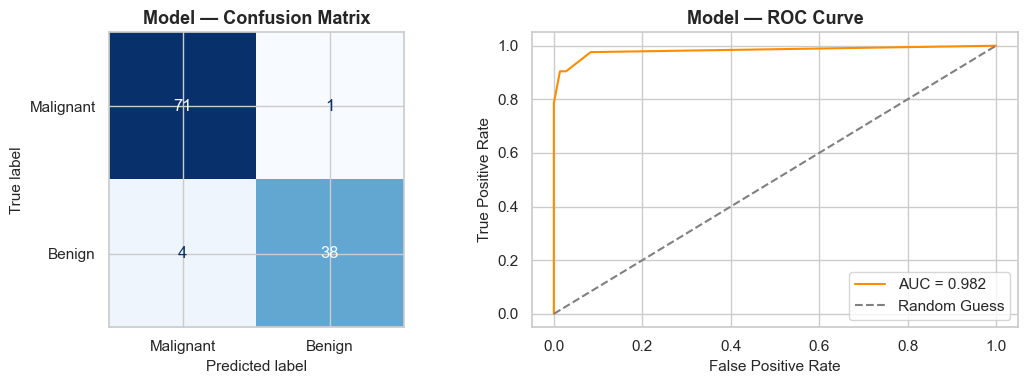

===== Model — Evaluation Metrics =====
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
ROC AUC: 0.9944

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      1.00      0.97        72
      Benign       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



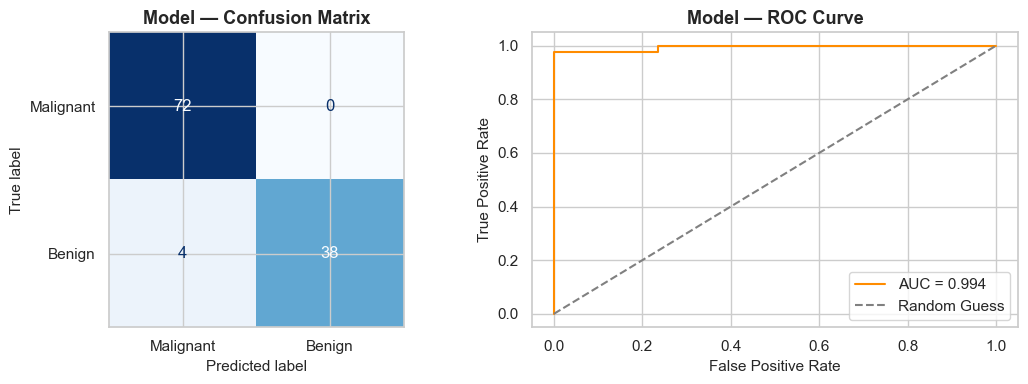

===== Model — Evaluation Metrics =====
Accuracy: 0.9298
Precision: 0.9048
Recall: 0.9048
F1 Score: 0.9048
ROC AUC: 0.9246

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.94      0.94      0.94        72
      Benign       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



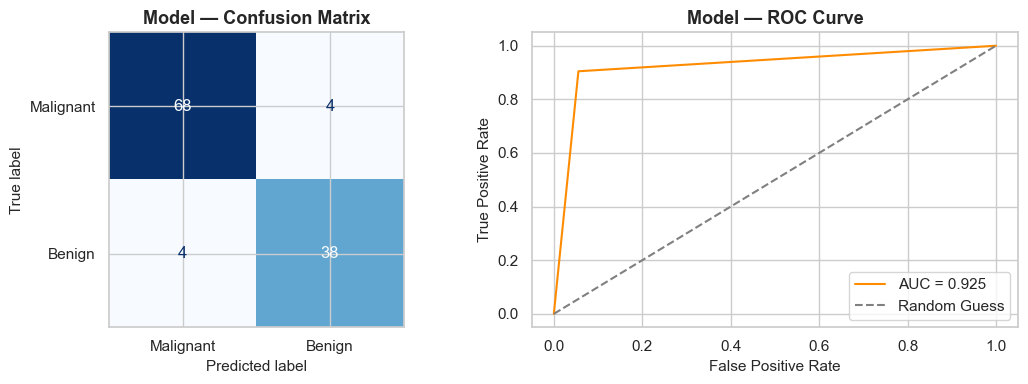

===== Model — Evaluation Metrics =====
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
ROC AUC: 0.9944

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      1.00      0.97        72
      Benign       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



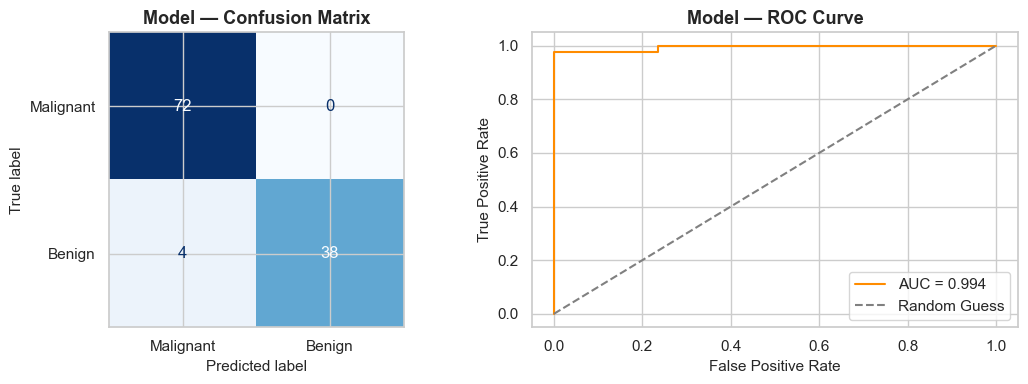

===== Model — Evaluation Metrics =====
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
ROC AUC: 0.9914

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      1.00      0.97        72
      Benign       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



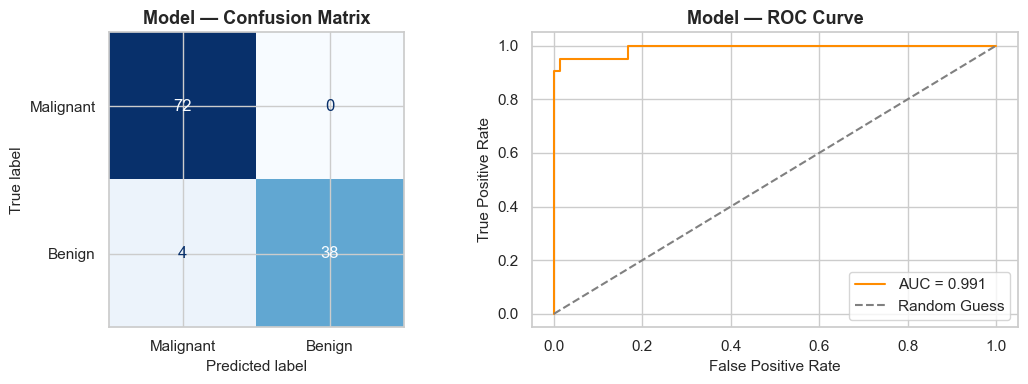

===== Model — Evaluation Metrics =====
Accuracy: 0.9649
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
ROC AUC: 0.9937

===== Model — Classification Report =====
              precision    recall  f1-score   support

   Malignant       0.95      1.00      0.97        72
      Benign       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



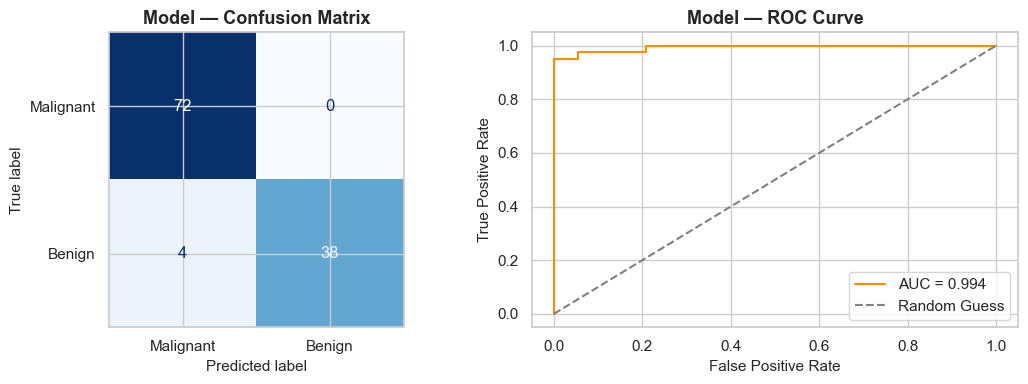

,Accuracy,Precision,Recall,F1 Score,ROC AUC
KNN,0.9561,0.9744,0.9048,0.9383,0.9823
Logistic Regression,0.9649,1.0000,0.9048,0.9500,0.9944
Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246
Naive Bayes,0.9649,1.0000,0.9048,0.9500,0.9944
SVM,0.9649,1.0000,0.9048,0.9500,0.9914
Neural Network,0.9649,1.0000,0.9048,0.9500,0.9937


In [357]:
comparison = pd.DataFrame(
    [
        evaluate_model(knn_model, X_test_scaled, y_test),
        evaluate_model(model, X_test, y_test),
        evaluate_model(tree_model, X_test, y_test),
        evaluate_model(model, X_test, y_test),
        evaluate_model(svm_linear, X_test_scaled, y_test),
        evaluate_model(nn_model, X_test_scaled, y_test),
    ],
    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    index=[
        "KNN",
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes",
        "SVM",
        "Neural Network"
    ]
)

comparison = comparison.round(4)

comparison